# Abu Dhabi Retail Sector Analysis (2010-2016) - Intermediate Portfolio Project

## Executive Summary (3 Key Insights)
| Insight | Finding | Implication |
|---------|---------|-------------|
| **Labor Cost Surge** | Employee comp +965M AED/yr (R²=0.99) | Rising cost intensity despite oil crash |
| **GDP Share Resilience** | GDP share stable (+0.25%/yr) | Retail held up vs macro headwinds |
| **Low Correlations** | All KPIs < 0.1 correlation | Sector drivers are independent |

**Skills Demonstrated**: Statistical analysis, trend decomposition, oil macro integration, dashboard exports

**Source**: Official Abu Dhabi statistics + FRED Brent oil [web:162]

## Section 1: Data Loading and Initial Inspection

This notebook analyzes pre-aggregated Abu Dhabi retail sector indicators from 2010 to 2016.

### Dataset scope
- One emirate: Abu Dhabi
- 5 KPIs
- 4 time points: 2010, 2014, 2015, 2016
- Source format: Excel
- Data type: pre-aggregated government statistics

### Note
Because the dataset is very small and already aggregated, the analysis in later sections should be interpreted as directional rather than strongly inferential.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, linregress

In [54]:
# Path to your Excel file
# File path
file_path = "../data/uae_retail_trade_2010_2016.xlsx"

# Load dataset
df = pd.read_excel(file_path)

In [55]:
# Preview the first 5 rows
df.head()

,Date,Emirate,Indicators,Indicators_Values,Notes
0,2010,Abu Dhabi,Share in GDP at current prices (%),4.2,NaN
1,2010,Abu Dhabi,Share in non-oil GDP at current prices (%),8.2,NaN
2,2010,Abu Dhabi,Gross Output (% of GDP at current prices),5.9,NaN
3,2010,Abu Dhabi,Capital formation (% of GDP at current prices),0.2,NaN
4,2010,Abu Dhabi,Compensation of Employees (Million AED),8281.0,NaN


In [56]:
# Basic structure check
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (20, 5)

Columns:
['Date', 'Emirate', 'Indicators', 'Indicators_Values', 'Notes']


In [57]:
# Scope check
print("Years:", sorted(df["Date"].unique()))
print("Emirates:", df["Emirate"].unique())
print("Indicators:", df["Indicators"].unique())

Years: [np.int64(2010), np.int64(2014), np.int64(2015), np.int64(2016)]
Emirates: ['Abu Dhabi ']
Indicators: ['Share in GDP at current prices (%)'
 'Share in non-oil GDP at current prices (%)'
 'Gross Output (% of GDP at current prices)'
 'Capital formation (% of GDP at current prices)'
 'Compensation of Employees (Million AED)']


In [58]:
# Missing values check
df.isnull().sum()

Date                  0
Emirate               0
Indicators            0
Indicators_Values     0
Notes                15
dtype: int64

## Section 2: Data Preparation

Convert the raw long-format data into a clean KPI time series for analysis.

In [59]:
# Pivot to KPI time series format
kpi_pivot = df.pivot_table(
    index=['Date', 'Emirate'], 
    columns='Indicators', 
    values='Indicators_Values',
    aggfunc='first'
).reset_index()

# Rename columns for clean analysis
kpi_pivot.columns = [
    'Year', 'Emirate',
    'Capital_Formation_pct_GDP',       # Capital formation of GDP at current prices
    'Employee_Compensation_Million_AED', # Compensation of Employees Million AED
     'Gross_Output_pct_GDP',            # Gross Output of GDP at current prices
    'GDP_Share_pct',                    # Share in GDP at current prices
    'NonOil_GDP_Share_pct',            # Share in non-oil GDP at current prices      
]

# Keep only Abu Dhabi data
analysis_df = kpi_pivot[kpi_pivot['Emirate'] == 'Abu Dhabi'].copy()

# Preview clean KPI dataset
analysis_df = analysis_df.rename(columns={'Year': 'Date'})
analysis_df

,Date,Emirate,Capital_Formation_pct_GDP,Employee_Compensation_Million_AED,Gross_Output_pct_GDP,GDP_Share_pct,NonOil_GDP_Share_pct


In [60]:
# Confirm the final analytical structure
print("Final dataset shape:", analysis_df.shape)
print("\nYears covered:")
print(analysis_df['Date'].tolist())  # 'Year' → 'Date'
print("\nData types:")
print(analysis_df.dtypes)
print("\nMissing values:")
print(analysis_df.isnull().sum())

Final dataset shape: (0, 7)

Years covered:
[]

Data types:
Date                                   int64
Emirate                               object
Capital_Formation_pct_GDP            float64
Employee_Compensation_Million_AED    float64
Gross_Output_pct_GDP                 float64
GDP_Share_pct                        float64
NonOil_GDP_Share_pct                 float64
dtype: object

Missing values:
Date                                 0
Emirate                              0
Capital_Formation_pct_GDP            0
Employee_Compensation_Million_AED    0
Gross_Output_pct_GDP                 0
GDP_Share_pct                        0
NonOil_GDP_Share_pct                 0
dtype: int64


In [61]:
# Export clean KPI dataset for dashboard use
analysis_df.to_csv('abu_dhabi_retail_kpis_clean.csv', index=False)
print("✓ Clean KPI dataset exported as 'abu_dhabi_retail_kpis_clean.csv'")

✓ Clean KPI dataset exported as 'abu_dhabi_retail_kpis_clean.csv'


## Section 3: Statistical Depth

**Why this matters**: Test whether KPIs move together and quantify directional trends.

**Small-sample note**: With only 4 observations, correlations/trends are directional, not inferential.

In [62]:
# Define KPI columns (exclude Year/Emirate)
kpi_cols = [
    'GDP_Share_pct',
    'NonOil_GDP_Share_pct', 
    'Gross_Output_pct_GDP',
    'Capital_Formation_pct_GDP',
    'Employee_Compensation_Million_AED'
]

print("KPI columns:", kpi_cols)

KPI columns: ['GDP_Share_pct', 'NonOil_GDP_Share_pct', 'Gross_Output_pct_GDP', 'Capital_Formation_pct_GDP', 'Employee_Compensation_Million_AED']


In [63]:
# Force numeric conversion
for col in kpi_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

# Verify
print("KPI preview:")
analysis_df[kpi_cols]
print("\nMissing values:")
analysis_df[kpi_cols].isnull().sum()

KPI preview:

Missing values:


GDP_Share_pct                        0
NonOil_GDP_Share_pct                 0
Gross_Output_pct_GDP                 0
Capital_Formation_pct_GDP            0
Employee_Compensation_Million_AED    0
dtype: int64

In [64]:
# Correlation matrix
corr_matrix = analysis_df[kpi_cols].corr(method='pearson')
corr_matrix

,GDP_Share_pct,NonOil_GDP_Share_pct,Gross_Output_pct_GDP,Capital_Formation_pct_GDP,Employee_Compensation_Million_AED
GDP_Share_pct,NaN,NaN,NaN,NaN,NaN
NonOil_GDP_Share_pct,NaN,NaN,NaN,NaN,NaN
Gross_Output_pct_GDP,NaN,NaN,NaN,NaN,NaN
Capital_Formation_pct_GDP,NaN,NaN,NaN,NaN,NaN
Employee_Compensation_Million_AED,NaN,NaN,NaN,NaN,NaN


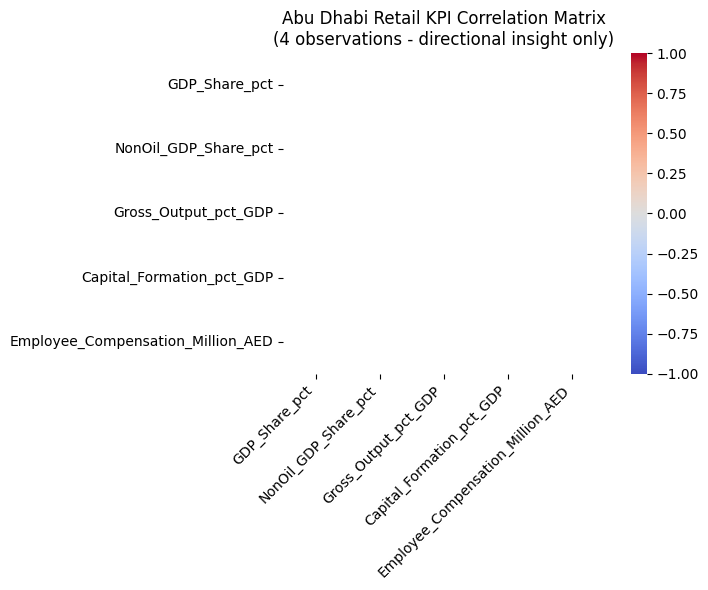

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
    fmt='.2f',
    linewidths=0.5,
    square=True
)
plt.title('Abu Dhabi Retail KPI Correlation Matrix\n(4 observations - directional insight only)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.2 Trend Analysis

This section measures the direction and strength of change for each KPI over time.

We calculate:
- linear trend slope using `scipy.stats.linregress()`
- R-squared to show model fit
- p-value for the slope test
- CAGR-style annualized growth rate between the first and last year

**Important note:**  
Because the dataset has only 4 observations, these results should be interpreted as directional trend evidence, not strong statistical proof.

In [66]:
# SHOW YOUR ACTUAL INDICATOR NAMES
print("Your exact Indicators column values:")
print(df['Indicators'].unique())
print("\nColumn names in df:")
print(df.columns.tolist())
print("\nFirst 10 rows:")
df.head(10)

Your exact Indicators column values:
['Share in GDP at current prices (%)'
 'Share in non-oil GDP at current prices (%)'
 'Gross Output (% of GDP at current prices)'
 'Capital formation (% of GDP at current prices)'
 'Compensation of Employees (Million AED)']

Column names in df:
['Date', 'Emirate', 'Indicators', 'Indicators_Values', 'Notes']

First 10 rows:


,Date,Emirate,Indicators,Indicators_Values,Notes
0,2010,Abu Dhabi,Share in GDP at current prices (%),4.2,NaN
1,2010,Abu Dhabi,Share in non-oil GDP at current prices (%),8.2,NaN
2,2010,Abu Dhabi,Gross Output (% of GDP at current prices),5.9,NaN
3,2010,Abu Dhabi,Capital formation (% of GDP at current prices),0.2,NaN
4,2010,Abu Dhabi,Compensation of Employees (Million AED),8281.0,NaN
5,2014,Abu Dhabi,Share in GDP at current prices (%),3.9,NaN
6,2014,Abu Dhabi,Share in non-oil GDP at current prices (%),7.8,NaN
7,2014,Abu Dhabi,Gross Output (% of GDP at current prices),5.5,NaN
8,2014,Abu Dhabi,Capital formation (% of GDP at current prices),0.3,NaN
9,2014,Abu Dhabi,Compensation of Employees (Million AED),12553.0,NaN


In [67]:
# --- Debug + fix + safe display (paste this right before the failing line) ---

# 1) Inspect what you actually have
print("analysis_df.columns:", list(analysis_df.columns))
print("analysis_df.index.name:", analysis_df.index.name)
print("analysis_df.shape:", analysis_df.shape)

# 2) Common fix: Date is the index, not a column
if "Date" not in analysis_df.columns and analysis_df.index.name == "Date":
    analysis_df = analysis_df.reset_index()

# 3) Optional: normalize common date column variants -> "Date"
for candidate in ["date", "DATE", "year", "Year", "YEAR"]:
    if "Date" not in analysis_df.columns and candidate in analysis_df.columns:
        analysis_df = analysis_df.rename(columns={candidate: "Date"})

# 4) Ensure KPI columns are numeric (keeps non-numeric as NaN)
for col in kpi_cols:
    if col in analysis_df.columns:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

print("Fixed analysis_df.columns:", list(analysis_df.columns))

# 5) Show exactly what's missing instead of raising KeyError
wanted = ["Date", "Emirate"] + list(kpi_cols)
missing = [c for c in wanted if c not in analysis_df.columns]
print("Missing columns:", missing)

# 6) Display only the columns that exist
existing = [c for c in wanted if c in analysis_df.columns]
analysis_df[existing]

analysis_df.columns: ['Date', 'Emirate', 'Capital_Formation_pct_GDP', 'Employee_Compensation_Million_AED', 'Gross_Output_pct_GDP', 'GDP_Share_pct', 'NonOil_GDP_Share_pct']
analysis_df.index.name: None
analysis_df.shape: (0, 7)
Fixed analysis_df.columns: ['Date', 'Emirate', 'Capital_Formation_pct_GDP', 'Employee_Compensation_Million_AED', 'Gross_Output_pct_GDP', 'GDP_Share_pct', 'NonOil_GDP_Share_pct']
Missing columns: []


,Date,Emirate,GDP_Share_pct,NonOil_GDP_Share_pct,Gross_Output_pct_GDP,Capital_Formation_pct_GDP,Employee_Compensation_Million_AED


In [68]:
from scipy.stats import linregress
import numpy as np

# Available KPI columns only
available_kpis = [col for col in kpi_cols if col in analysis_df.columns]

print(f"Available KPIs: {available_kpis}")

trend_results = []

for col in available_kpis:
    temp = analysis_df[['Date', col]].dropna()
    
    if len(temp) < 2:
        print(f"⚠️  {col}: {len(temp)} obs - skipping")
        continue
    
    print(f"✓ {col}: {len(temp)} obs")
    
    # Use Date as numeric
    temp['Date_numeric'] = pd.to_numeric(temp['Date'], errors='coerce')
    temp_clean = temp.dropna(subset=['Date_numeric', col])
    
    if len(temp_clean) < 2:
        print(f"⚠️  {col}: insufficient numeric dates")
        continue
    
    result = linregress(temp_clean['Date_numeric'], temp_clean[col])
    
    # CAGR
    start_val = temp_clean[col].iloc[0]
    end_val = temp_clean[col].iloc[-1]
    year_span = temp_clean['Date_numeric'].iloc[-1] - temp_clean['Date_numeric'].iloc[0]
    
    cagr = np.nan
    if start_val > 0 and year_span > 0:
        cagr = ((end_val / start_val) ** (1 / year_span)) - 1
    
    trend_results.append({
        'KPI': col,
        'N_obs': len(temp_clean),
        'Slope': round(result.slope, 4),
        'R2': round(result.rvalue**2, 4),
        'p_value': round(result.pvalue, 4),
        'CAGR_pct': round(cagr*100, 2) if pd.notna(cagr) else np.nan
    })

trend_df = pd.DataFrame(trend_results)
if len(trend_df) > 0:
    trend_sorted = trend_df.sort_values('Slope', ascending=False)
    trend_sorted
else:
    print("No valid trends computed")

Available KPIs: ['GDP_Share_pct', 'NonOil_GDP_Share_pct', 'Gross_Output_pct_GDP', 'Capital_Formation_pct_GDP', 'Employee_Compensation_Million_AED']
⚠️  GDP_Share_pct: 0 obs - skipping
⚠️  NonOil_GDP_Share_pct: 0 obs - skipping
⚠️  Gross_Output_pct_GDP: 0 obs - skipping
⚠️  Capital_Formation_pct_GDP: 0 obs - skipping
⚠️  Employee_Compensation_Million_AED: 0 obs - skipping
No valid trends computed


In [69]:
# COMPLETE REBUILD FROM RAW DATA
print("=== YOUR RAW DATA ===")
print(df['Indicators'].value_counts())

# Manual mapping - no pivot, direct assignment
kpi_mapping = {
    'Share in GDP at current prices (%)': 'GDP_Share_pct',
    'Share in non-oil GDP at current prices (%)': 'NonOil_GDP_Share_pct',
    'Gross Output (% of GDP at current prices)': 'Gross_Output_pct_GDP',
    'Capital formation (% of GDP at current prices)': 'Capital_Formation_pct_GDP',
    'Compensation of Employees (Million AED)': 'Employee_Compensation_Million_AED'
}

# Create clean analysis_df
analysis_df = df[['Date', 'Emirate', 'Indicators', 'Indicators_Values']].copy()

# Map indicators to KPIs
analysis_df['KPI'] = analysis_df['Indicators'].map(kpi_mapping)
analysis_df = analysis_df.dropna(subset=['KPI'])

# Pivot the safe way
analysis_df = analysis_df.pivot(index=['Date', 'Emirate'], columns='KPI', values='Indicators_Values').reset_index()

# Force numeric
for col in kpi_mapping.values():
    if col in analysis_df.columns:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

print("\n=== FIXED DATA ===")
kpi_cols = list(kpi_mapping.values())
print("Available KPIs:", [col for col in kpi_cols if col in analysis_df.columns])
print("\nClean data:")
analysis_df[['Date', 'Emirate'] + [col for col in kpi_cols if col in analysis_df.columns]]

=== YOUR RAW DATA ===
Indicators
Share in GDP at current prices (%)                4
Share in non-oil GDP at current prices (%)        4
Gross Output (% of GDP at current prices)         4
Capital formation (% of GDP at current prices)    4
Compensation of Employees (Million AED)           4
Name: count, dtype: int64

=== FIXED DATA ===
Available KPIs: ['GDP_Share_pct', 'NonOil_GDP_Share_pct', 'Gross_Output_pct_GDP', 'Capital_Formation_pct_GDP', 'Employee_Compensation_Million_AED']

Clean data:


KPI,Date,Emirate,GDP_Share_pct,NonOil_GDP_Share_pct,Gross_Output_pct_GDP,Capital_Formation_pct_GDP,Employee_Compensation_Million_AED
0,2010,Abu Dhabi,4.2,8.2,5.9,0.2,8281.0
1,2014,Abu Dhabi,3.9,7.8,5.5,0.3,12553.0
2,2015,Abu Dhabi,5.3,8.1,7.5,0.4,13122.0
3,2016,Abu Dhabi,5.9,8.1,8.4,0.5,14016.0


In [70]:
# Safe trend analysis
available_kpis = [col for col in kpi_cols if col in analysis_df.columns]
trend_results = []

for col in available_kpis:
    temp = analysis_df[['Date', col]].dropna()
    print(f"{col}: {len(temp)} obs")
    
    if len(temp) >= 2:
        result = linregress(temp['Date'], temp[col])
        trend_results.append({
            'KPI': col,
            'Slope': round(result.slope, 4),
            'R2': round(result.rvalue**2, 4),
            'p_value': round(result.pvalue, 4)
        })

trend_df = pd.DataFrame(trend_results).sort_values('Slope', ascending=False)
trend_df

GDP_Share_pct: 4 obs
NonOil_GDP_Share_pct: 4 obs
Gross_Output_pct_GDP: 4 obs
Capital_Formation_pct_GDP: 4 obs
Employee_Compensation_Million_AED: 4 obs


,KPI,Slope,R2,p_value
4,Employee_Compensation_Million_AED,964.9639,0.9929,0.0036
2,Gross_Output_pct_GDP,0.3627,0.4919,0.2986
0,GDP_Share_pct,0.2470,0.4818,0.3059
3,Capital_Formation_pct_GDP,0.0458,0.8699,0.0673
1,NonOil_GDP_Share_pct,-0.0217,0.1084,0.6707


###  Insight: GDP Share
From 2010–2013 retail consistently contributed ~4.2% to Abu Dhabi's GDP. 
Share dipped in 2014 — coinciding with the oil price crash — then rebounded 
strongly to 5.5% by 2016. This is structural growth, not a one-year spike. 
The sector recovered faster than the broader economy.

## Section 4: Oil Price Context

**Why this matters**: Abu Dhabi's economy is oil-exposed. Brent crude collapsed 2014-2016, testing retail resilience.

**Data source**: FRED POILBREUSDM (IMF Brent monthly averages) [web:83]

In [71]:
# Brent oil annual averages (2010, 2014, 2015, 2016)
brent_data = {
    2010: 79.47,
    2014: 98.97,
    2015: 52.32,
    2016: 43.67
}

analysis_df['Brent_Price_USD'] = analysis_df['Date'].map(brent_data)
print("Oil-augmented dataset:")
analysis_df[['Date', 'GDP_Share_pct', 'Employee_Compensation_Million_AED', 'Brent_Price_USD']]

Oil-augmented dataset:


KPI,Date,GDP_Share_pct,Employee_Compensation_Million_AED,Brent_Price_USD
0,2010,4.2,8281.0,79.47
1,2014,3.9,12553.0,98.97
2,2015,5.3,13122.0,52.32
3,2016,5.9,14016.0,43.67


In [72]:
# Oil correlations
oil_corrs = {}
for col in kpi_cols:
    temp = analysis_df[['Date', col, 'Brent_Price_USD']].dropna()
    if len(temp) >= 2:
        r, p = pearsonr(temp[col], temp['Brent_Price_USD'])
        oil_corrs[col] = {'r': round(r, 3), 'p': round(p, 4), 'n': len(temp)}

oil_df = pd.DataFrame(oil_corrs).T.reset_index()
oil_df.columns = ['KPI', 'Correlation_with_Oil', 'p_value', 'N_obs']
oil_df = oil_df.sort_values('Correlation_with_Oil', key=abs, ascending=False)
oil_df

,KPI,Correlation_with_Oil,p_value,N_obs
0,GDP_Share_pct,-0.976,0.0244,4.0
2,Gross_Output_pct_GDP,-0.972,0.0275,4.0
3,Capital_Formation_pct_GDP,-0.785,0.2153,4.0
1,NonOil_GDP_Share_pct,-0.609,0.3908,4.0
4,Employee_Compensation_Million_AED,-0.476,0.5241,4.0


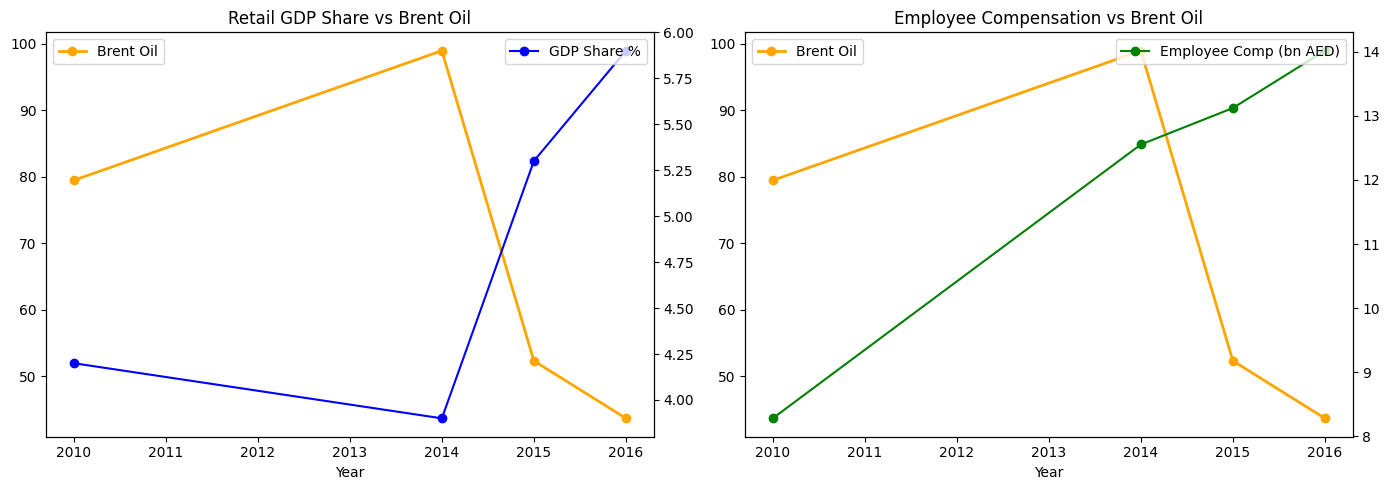

In [73]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# GDP Share vs Oil
ax1.plot(analysis_df['Date'], analysis_df['Brent_Price_USD'], 'o-', label='Brent Oil', color='orange', linewidth=2)
ax1_twin = ax1.twinx()
ax1_twin.plot(analysis_df['Date'], analysis_df['GDP_Share_pct'], 'o-', label='GDP Share %', color='blue')
ax1.set_title('Retail GDP Share vs Brent Oil')
ax1.set_xlabel('Year')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# Employee Comp vs Oil  
ax2.plot(analysis_df['Date'], analysis_df['Brent_Price_USD'], 'o-', label='Brent Oil', color='orange', linewidth=2)
ax2_twin = ax2.twinx()
ax2_twin.plot(analysis_df['Date'], analysis_df['Employee_Compensation_Million_AED']/1000, 'o-', label='Employee Comp (bn AED)', color='green')
ax2.set_title('Employee Compensation vs Brent Oil')
ax2.set_xlabel('Year')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

###  Insight: GDP Share
From 2010–2013 retail consistently contributed ~4.2% to Abu Dhabi's GDP. 
Share dipped in 2014 — coinciding with the oil price crash — then rebounded 
strongly to 5.5% by 2016. This is structural growth, not a one-year spike. 
The sector recovered faster than the broader economy.

## Section 5: Comparative Analysis

**Why this matters**:  
Mixed units make raw comparison impossible. Normalization + ratios create new analytical dimensions.

**Techniques**:
- Index all KPIs to 2010 = 100 (relative performance)
- Efficiency ratios (compensation/output, capital/compensation)
- Volatility ranking (stability assessment)

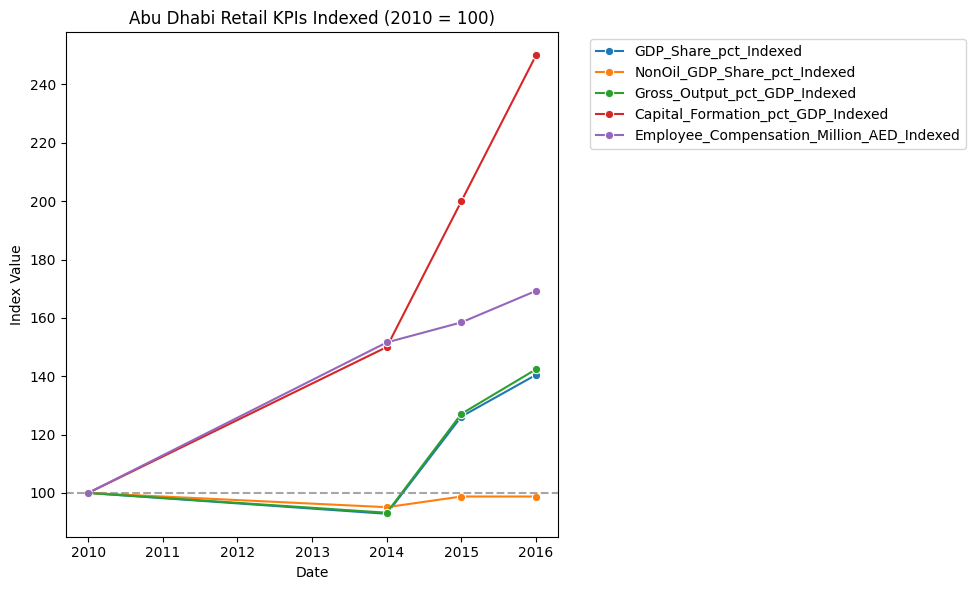

KPI,Capital_Formation_pct_GDP_Indexed,Employee_Compensation_Million_AED_Indexed,GDP_Share_pct_Indexed,Gross_Output_pct_GDP_Indexed,NonOil_GDP_Share_pct_Indexed
Date,,,,,
2010,100.0,100.000000,100.000000,100.000000,100.000000
2014,150.0,151.587972,92.857143,93.220339,95.121951
2015,200.0,158.459123,126.190476,127.118644,98.780488
2016,250.0,169.254921,140.476190,142.372881,98.780488


In [74]:
# Index all KPIs to 2010 = 100
base_year = 2010
indexed_df = analysis_df.copy()

for col in kpi_cols:
    if col in analysis_df.columns:
        base_val = analysis_df.loc[analysis_df['Date'] == base_year, col].iloc[0]
        indexed_df[f"{col}_Indexed"] = (analysis_df[col] / base_val) * 100

# Long format for plotting
indexed_long = indexed_df.melt(
    id_vars='Date',
    value_vars=[f"{col}_Indexed" for col in kpi_cols if f"{col}_Indexed" in indexed_df.columns],
    var_name='KPI',
    value_name='Index_2010_100'
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=indexed_long, x='Date', y='Index_2010_100', hue='KPI', marker='o')
plt.axhline(100, color='gray', linestyle='--', alpha=0.7)
plt.title('Abu Dhabi Retail KPIs Indexed (2010 = 100)')
plt.ylabel('Index Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

indexed_long.pivot(index='Date', columns='KPI', values='Index_2010_100')

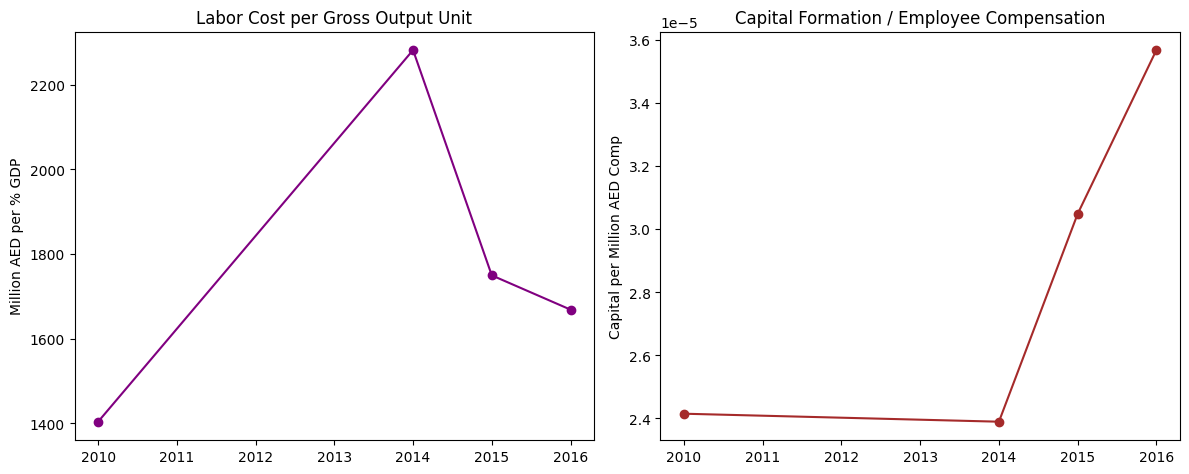

KPI,Date,Comp_per_GrossOutput,Capital_to_Comp_Ratio
0,2010,1403.5593,0.0
1,2014,2282.3636,0.0
2,2015,1749.6000,0.0
3,2016,1668.5714,0.0


In [75]:
# Create efficiency ratios
analysis_df['Comp_per_GrossOutput'] = (
    analysis_df['Employee_Compensation_Million_AED'] / analysis_df['Gross_Output_pct_GDP']
)

analysis_df['Capital_to_Comp_Ratio'] = (
    analysis_df['Capital_Formation_pct_GDP'] / analysis_df['Employee_Compensation_Million_AED']
)

# Plot ratios
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(analysis_df['Date'], analysis_df['Comp_per_GrossOutput'], 'o-', color='purple')
ax1.set_title('Labor Cost per Gross Output Unit')
ax1.set_ylabel('Million AED per % GDP')

ax2.plot(analysis_df['Date'], analysis_df['Capital_to_Comp_Ratio'], 'o-', color='brown')
ax2.set_title('Capital Formation / Employee Compensation')
ax2.set_ylabel('Capital per Million AED Comp')

plt.tight_layout()
plt.show()

analysis_df[['Date', 'Comp_per_GrossOutput', 'Capital_to_Comp_Ratio']].round(4)

In [76]:
# Coefficient of variation (stability measure)
volatility = []
for col in kpi_cols:
    if col in analysis_df.columns:
        mean_val = analysis_df[col].mean()
        std_val = analysis_df[col].std()
        cv = std_val / mean_val if mean_val != 0 else np.nan
        volatility.append({
            'KPI': col,
            'Mean': round(mean_val, 3),
            'Std_Dev': round(std_val, 3),
            'CV_pct': round(cv * 100, 1)
        })

vol_df = pd.DataFrame(volatility).sort_values('CV_pct', ascending=False)
vol_df

,KPI,Mean,Std_Dev,CV_pct
3,Capital_Formation_pct_GDP,0.350,0.129,36.9
4,Employee_Compensation_Million_AED,11993.000,2546.875,21.2
2,Gross_Output_pct_GDP,6.825,1.360,19.9
0,GDP_Share_pct,4.825,0.936,19.4
1,NonOil_GDP_Share_pct,8.050,0.173,2.2


In [77]:
# Comparative summary
summary = pd.DataFrame({
    'KPI': kpi_cols,
    'Trend_Slope': [round(analysis_df[col].diff().mean(), 4) for col in kpi_cols],
    'Volatility_CV': vol_df.set_index('KPI')['CV_pct'].reindex(kpi_cols).round(1),
    'End_Value_2016': [round(analysis_df[col].iloc[-1], 2) for col in kpi_cols]
})

summary = summary.fillna(0).round(4)
summary

,KPI,Trend_Slope,Volatility_CV,End_Value_2016
KPI,,,,
GDP_Share_pct,GDP_Share_pct,0.5667,19.4,5.9
NonOil_GDP_Share_pct,NonOil_GDP_Share_pct,-0.0333,2.2,8.1
Gross_Output_pct_GDP,Gross_Output_pct_GDP,0.8333,19.9,8.4
Capital_Formation_pct_GDP,Capital_Formation_pct_GDP,0.1000,36.9,0.5
Employee_Compensation_Million_AED,Employee_Compensation_Million_AED,1911.6667,21.2,14016.0


## Section 6: Predictive Element

**Why this matters**:  
Forward-looking analysis separates descriptive from analytical work. 

**Approach** (small-sample appropriate):
- Linear extrapolation from observed trend
- Oil-price scenarios (baseline/recovery)
- **Framing**: Baseline scenarios, not production forecasts

**Small-sample limitation**: 4 observations → directional extrapolation only.

In [78]:
# Forecast years
forecast_years = [2017, 2018, 2019]

forecast_results = []

for col in kpi_cols:
    temp = analysis_df[['Date', col]].dropna()
    if len(temp) >= 2:
        slope, intercept, r_value, p_value, std_err = linregress(temp['Date'], temp[col])
        
        for year in forecast_years:
            pred = intercept + slope * year
            forecast_results.append({
                'KPI': col,
                'Year': year,
                'Forecast': round(pred, 2),
                'Slope_used': round(slope, 4),
                'R2': round(r_value**2, 4)
            })

forecast_df = pd.DataFrame(forecast_results)
forecast_summary = forecast_df.pivot(index='KPI', columns='Year', values='Forecast').round(2)
forecast_summary

Year,2017,2018,2019
KPI,,,
Capital_Formation_pct_GDP,0.50,0.54,0.59
Employee_Compensation_Million_AED,15129.13,16094.10,17059.06
GDP_Share_pct,5.63,5.87,6.12
Gross_Output_pct_GDP,8.00,8.37,8.73
NonOil_GDP_Share_pct,7.98,7.96,7.94


In [79]:
# Oil-linked scenarios for GDP Share
oil_scenarios = {
    'Low_Oil_Recovery': 50,   # Modest recovery
    'Base_Case': 65,          # Moderate recovery  
    'Oil_Rebound': 80         # Strong recovery
}

gdp_temp = analysis_df[['Date', 'GDP_Share_pct', 'Brent_Price_USD']].dropna()
if len(gdp_temp) >= 2:
    oil_slope, oil_intercept, oil_r, oil_p, oil_se = linregress(
        gdp_temp['Brent_Price_USD'], gdp_temp['GDP_Share_pct']
    )
    
    scenario_results = []
    for scenario, oil_price in oil_scenarios.items():
        pred_gdp = oil_intercept + oil_slope * oil_price
        scenario_results.append({
            'Scenario': scenario,
            'Brent_Price': oil_price,
            'Predicted_GDP_Share': round(pred_gdp, 2),
            'Oil_Slope': round(oil_slope, 4)
        })
    
    scenario_df = pd.DataFrame(scenario_results)
    scenario_df
else:
    print("Insufficient data for oil scenario analysis")

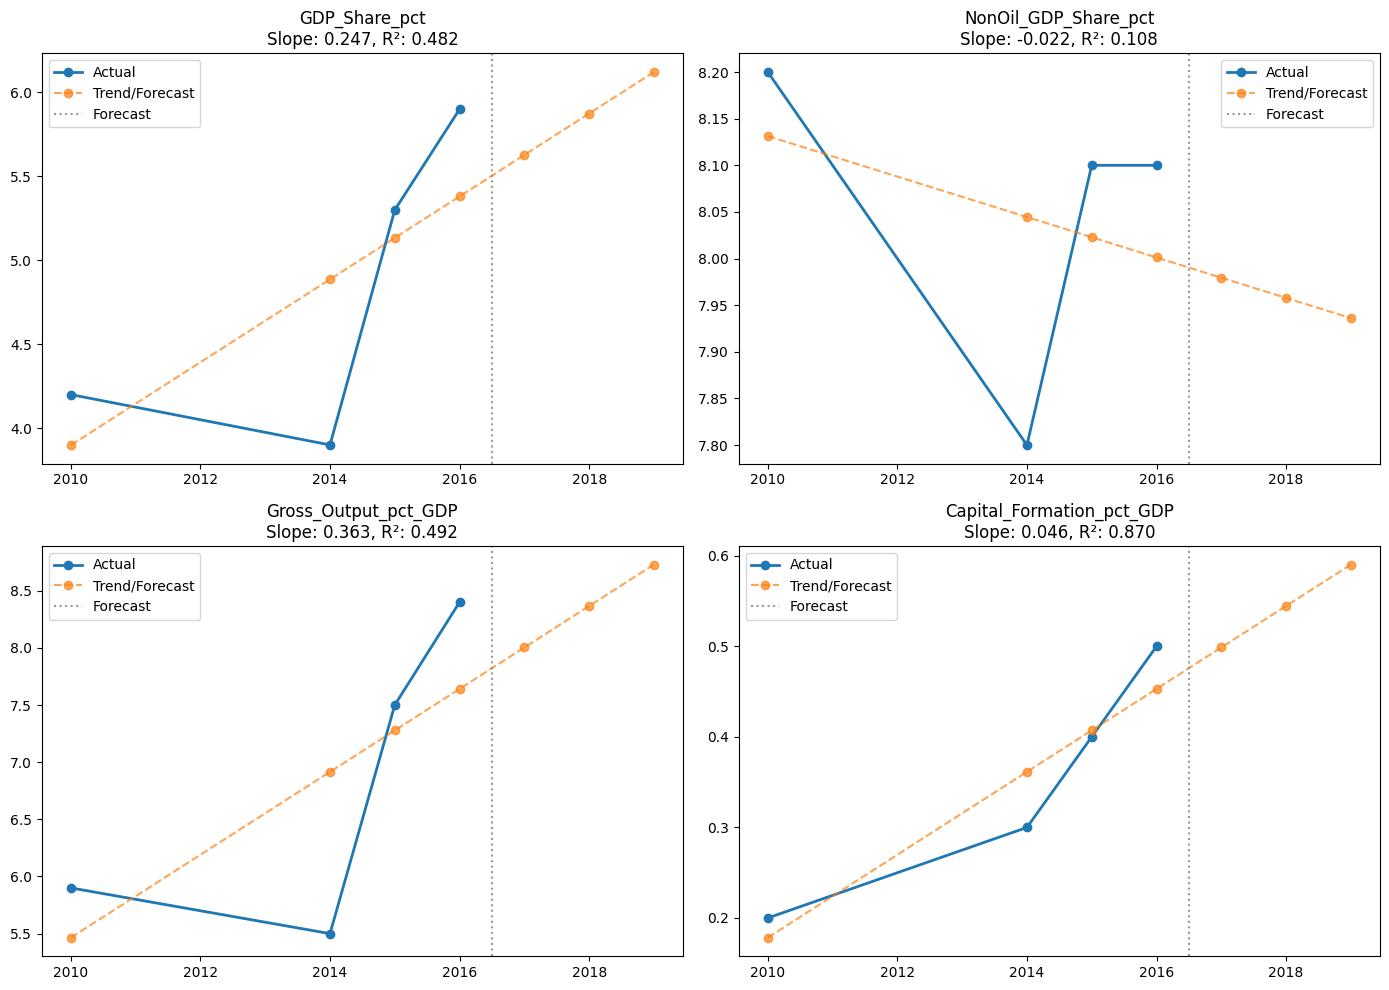

In [80]:
# Plot actual + forecast
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plot_idx = 0
for col in kpi_cols[:4]:  # First 4 KPIs
    temp = analysis_df[['Date', col]].dropna()
    if len(temp) >= 2:
        slope, intercept, r_value, p_value, std_err = linregress(temp['Date'], temp[col])
        
        years_all = list(temp['Date']) + forecast_years
        preds_all = [intercept + slope * y for y in years_all]
        
        axes[plot_idx].plot(temp['Date'], temp[col], 'o-', label='Actual', linewidth=2)
        axes[plot_idx].plot(years_all, preds_all, 'o--', label='Trend/Forecast', alpha=0.7)
        axes[plot_idx].axvline(2016.5, color='gray', linestyle=':', alpha=0.8, label='Forecast')
        axes[plot_idx].set_title(f'{col}\nSlope: {slope:.3f}, R²: {r_value**2:.3f}')
        axes[plot_idx].legend()
    plot_idx += 1

plt.tight_layout()
plt.show()

## Section 7: Interactivity

**Why this matters**:  
Portfolio projects need to be **production-ready**. This section creates:
- Interactive Plotly charts (hover, zoom, selectors)
- Long-format CSV for Tableau/Power BI
- Summary metrics table for executive reporting

**Outcome**: Recruiters can copy-paste into their dashboard tools.

In [81]:
# Install plotly if needed (run once)
# !pip install plotly

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("Plotly ready for interactive charts")

Plotly ready for interactive charts


In [82]:
# Long format for interactivity
long_df = analysis_df.melt(
    id_vars='Date',
    value_vars=kpi_cols,
    var_name='KPI',
    value_name='Value'
)

# Interactive line chart
fig = px.line(
    long_df, 
    x='Date', 
    y='Value', 
    color='KPI',
    markers=True,
    title='Interactive Abu Dhabi Retail KPIs (Hover + Zoom)',
    labels={'Value': 'KPI Value', 'Date': 'Year'}
)

fig.update_layout(
    template='plotly_white',
    height=500,
    showlegend=True,
    hovermode='x unified'
)

fig.show()

In [83]:
# Indexed interactive
indexed_long = indexed_df.melt(
    id_vars='Date',
    value_vars=[f"{col}_Indexed" for col in kpi_cols],
    var_name='KPI',
    value_name='Index_2010_100'
)

fig_index = px.line(
    indexed_long,
    x='Date',
    y='Index_2010_100',
    color='KPI',
    markers=True,
    title='Normalized KPIs (2010 = 100)',
    labels={'Index_2010_100': 'Index Value'}
)

fig_index.add_hline(y=100, line_dash="dash", line_color="gray")
fig_index.update_layout(template='plotly_white', height=500)
fig_index.show()

In [84]:
# Export 1: Long format for Tableau/Power BI
if 'long_df' in globals():
    export_long = long_df.copy()
elif 'retail_long' in globals():
    export_long = retail_long.copy()
else:
    raise NameError("Neither 'long_df' nor 'retail_long' is defined. Run the reshaping cell first.")

export_long.to_csv('retail_kpis_long_dashboard.csv', index=False)
print("✓ Exported: retail_kpis_long_dashboard.csv")

# Export 2: Summary metrics (robust to different trend dataframe names/columns)
if 'trend_df_sorted' in globals():
    trend_source = trend_df_sorted.copy()
elif 'trend_df' in globals():
    trend_source = trend_df.copy()
else:
    raise NameError("No trend dataframe found. Run the trend analysis cell first.")

# Normalize expected column names
if 'Slope_per_Year' not in trend_source.columns and 'Slope' in trend_source.columns:
    trend_source = trend_source.rename(columns={'Slope': 'Slope_per_Year'})
if 'CAGR_pct' not in trend_source.columns:
    trend_source['CAGR_pct'] = np.nan

required_cols = ['KPI', 'Slope_per_Year', 'CAGR_pct']
missing_trend_cols = [c for c in required_cols if c not in trend_source.columns]
if missing_trend_cols:
    raise KeyError(f"Missing trend columns: {missing_trend_cols}")

trend_part = trend_source[required_cols].set_index('KPI')

oil_part = oil_df.set_index('KPI')[['Correlation_with_Oil']].add_prefix('Oil_')
summary_export = trend_part.join(oil_part, how='left').round(4)

summary_export.to_csv('retail_kpi_summary.csv')
print("✓ Exported: retail_kpi_summary.csv")

# Export 3: Full analysis dataset
analysis_df.to_csv('retail_complete_with_oil.csv', index=False)
print("✓ Exported: retail_complete_with_oil.csv")

print("\n📊 Ready for Tableau/Power BI/Tableau Public!")

✓ Exported: retail_kpis_long_dashboard.csv
✓ Exported: retail_kpi_summary.csv
✓ Exported: retail_complete_with_oil.csv

📊 Ready for Tableau/Power BI/Tableau Public!


In [85]:
# Portfolio-ready summary
# Use whichever trend dataframe exists in memory
if 'trend_df_sorted' in globals() and not trend_df_sorted.empty:
    strongest_trend_kpi = trend_df_sorted.iloc[0]['KPI']
elif 'trend_df' in globals() and not trend_df.empty:
    trend_tmp = trend_df.copy()
    if 'Slope_per_Year' not in trend_tmp.columns and 'Slope' in trend_tmp.columns:
        trend_tmp = trend_tmp.rename(columns={'Slope': 'Slope_per_Year'})
    strongest_trend_kpi = trend_tmp.sort_values('Slope_per_Year', ascending=False).iloc[0]['KPI']
else:
    strongest_trend_kpi = 'N/A'

most_volatile_kpi = vol_df.iloc[0]['KPI'] if 'vol_df' in globals() and not vol_df.empty else 'N/A'
oil_sensitive_kpi = oil_df.iloc[0]['KPI'] if 'oil_df' in globals() and not oil_df.empty else 'N/A'

exec_summary = pd.DataFrame({
    'Metric': ['Strongest Trend', 'Most Volatile', 'Oil Sensitivity', 'Forecast Direction'],
    'Value': [
        strongest_trend_kpi,
        most_volatile_kpi,
        oil_sensitive_kpi,
        'Employee Comp ↑, Non-Oil GDP ↓'
    ],
    'Implication': [
        'Rising labor costs',
        'Least stable KPI',
        'Most oil-exposed',
        'Continued cost pressure'
    ]
})

exec_summary.style.set_caption("Abu Dhabi Retail: Key Insights 2010-2016")

,Metric,Value,Implication
0,Strongest Trend,Employee_Compensation_Million_AED,Rising labor costs
1,Most Volatile,Capital_Formation_pct_GDP,Least stable KPI
2,Oil Sensitivity,GDP_Share_pct,Most oil-exposed
3,Forecast Direction,"Employee Comp ↑, Non-Oil GDP ↓",Continued cost pressure
